In [9]:
# Cell 1: imports and paths
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RAW_PATH = "../data/raw/customer_clv.csv"
CLEAN_PATH = "../data/processed/customer_clv_clean.csv"

In [16]:
df = pd.read_csv(RAW_PATH)

display(df.sample(5))
df.shape

df.info()

,customer_id,customer_age,gender,country,acquisition_channel,product_tier,tenure_months,monthly_spend,login_freq_monthly,feature_adoption,support_tickets_6m,nps_score,payment_failures_6m,referrals_made,days_since_login,customer_feedback,clv_12m
2019,CUST0005828,22,Female,CA,Direct,Basic,4,36.43,12,0.386,1,7.0,0,4,2,"It's fine. Does what it says, nothing special.",609.04
5169,CUST0003694,38,Female,US,Organic Search,Pro,9,66.13,13,0.434,0,7.0,0,1,5,Customer service was polite but couldn't fix m...,788.68
2062,CUST0003377,42,Non-Binary,AU,Email Campaign,Free,59,0.00,17,0.446,0,4.0,0,0,4,Three billing errors in six months... Their ac...,0.00
4708,CUST0002837,42,Male,SG,Paid Ads,Basic,19,28.51,8,0.046,1,0.0,0,3,4,Thinking about cancelling. Too many bugs and s...,432.72
177,CUST0001872,40,Female,FR,Social Media,Pro,10,105.51,12,0.218,0,0.0,0,1,57,Not worth the price. The competitor offers mor...,1077.13


<class 'pandas.DataFrame'>
RangeIndex: 7028 entries, 0 to 7027
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          7028 non-null   str    
 1   customer_age         7028 non-null   int64  
 2   gender               7028 non-null   str    
 3   country              7028 non-null   str    
 4   acquisition_channel  7028 non-null   str    
 5   product_tier         7028 non-null   str    
 6   tenure_months        7028 non-null   int64  
 7   monthly_spend        6450 non-null   float64
 8   login_freq_monthly   7028 non-null   int64  
 9   feature_adoption     6748 non-null   float64
 10  support_tickets_6m   7028 non-null   int64  
 11  nps_score            6467 non-null   float64
 12  payment_failures_6m  7028 non-null   int64  
 13  referrals_made       7028 non-null   int64  
 14  days_since_login     7028 non-null   int64  
 15  customer_feedback    6467 non-null   str    
 16 

In [ ]:
display(df.isna().sum().sort_values(ascending=False))

duplicates = df.drop(columns=["customer_id"]).duplicated().sum()
print("\nDuplicates excluding customer_id:", int(duplicates))
cat_cols = ['gender', 'product_tier', 'country', 'acquisition_channel', 'customer_feedback']
drop_cols = ['customer_id']
num_cols = df.dtypes[df.dtypes != 'str'].index.tolist()

fix_cols = ['product_tier', 'acquisition_channel', 'customer_feedback']




monthly_spend          578
customer_feedback      561
nps_score              561
feature_adoption       280
customer_id              0
acquisition_channel      0
customer_age             0
country                  0
gender                   0
login_freq_monthly       0
tenure_months            0
product_tier             0
support_tickets_6m       0
payment_failures_6m      0
referrals_made           0
days_since_login         0
clv_12m                  0
dtype: int64


Duplicates excluding customer_id: 28


In [35]:
display(num_cols)

['customer_age',
 'tenure_months',
 'monthly_spend',
 'login_freq_monthly',
 'feature_adoption',
 'support_tickets_6m',
 'nps_score',
 'payment_failures_6m',
 'referrals_made',
 'days_since_login',
 'clv_12m']

In [36]:
# display(df.describe())

# display(df.columns)



display(df['acquisition_channel'].value_counts())

acquisition_channel
Organic Search    1548
Paid Ads          1418
Referral          1209
Social Media      1148
Email Campaign     883
Direct             751
social media        13
REFERRAL            12
Email campaign       8
Social media         8
Paid ads             8
organic search       7
email campaign       7
Organic search       5
paid ads             3
Name: count, dtype: int64

# Distributuion

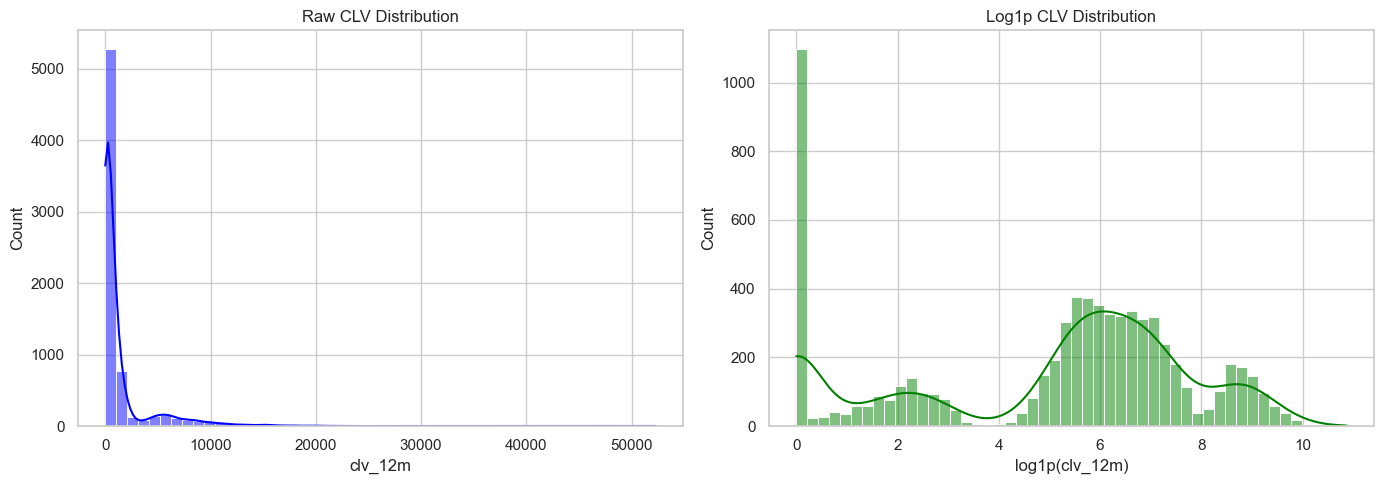

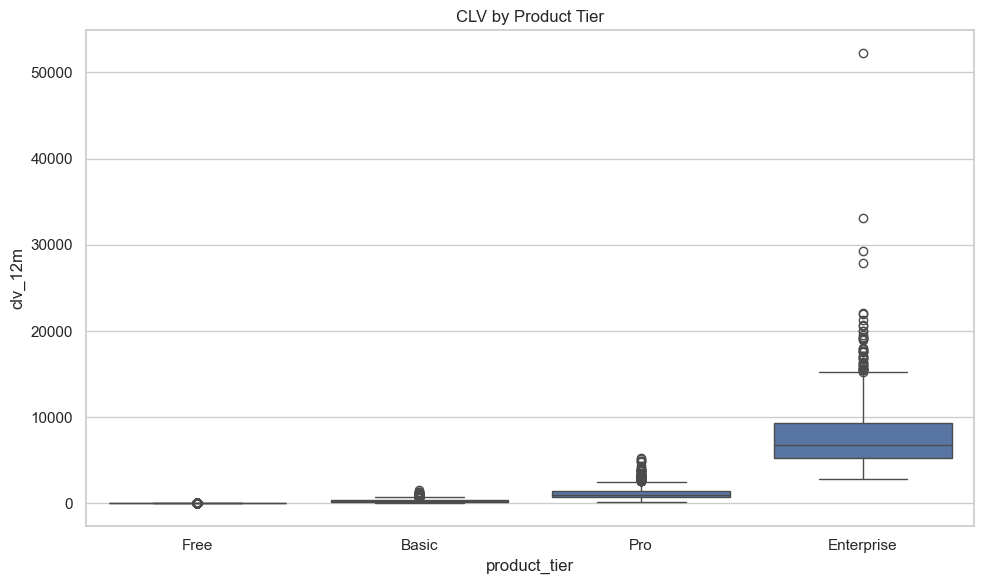

In [28]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["clv_12m"], bins=50, kde=True, ax=axes[0], color="blue")
axes[0].set_title("Raw CLV Distribution")
axes[0].set_xlabel("clv_12m")

sns.histplot(np.log1p(df["clv_12m"]), bins=50, kde=True, ax=axes[1], color="green")
axes[1].set_title("Log1p CLV Distribution")
axes[1].set_xlabel("log1p(clv_12m)")

plt.tight_layout()
plt.savefig("../reports/clv_distribution.png")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="product_tier", y="clv_12m", order=["Free", "Basic", "Pro", "Enterprise"])
plt.title("CLV by Product Tier")
plt.tight_layout()
plt.savefig("../reports/clv_by_product_tier.png")
plt.show()